# Goofy Screener — Phase 7: ML Signal Layer
**XGBoost · Feature Engineering · Time-Aware Validation**

---

## What Phase 7 adds

Phases 1–6 were all **rule-based**: fixed formulas, thresholds, and regime gates.
Phase 7 asks: *can a machine learning model find patterns in the data that our rules miss?*

We train an **XGBoost classifier** per asset that predicts:
> *Given today's technical conditions, will price be higher 20 trading days from now?*

The output is a **probability score (0–100%)** that acts as an additional gate:

| Phase 6 Verdict | ML Gate | P7 Verdict |
|---|---|---|
| TRADE | PASS (ML ≥ 55%) | **TRADE** |
| TRADE | HOLD (ML < 55%) | **ML HOLD** |
| STAND DOWN | any | **STAND DOWN** |

## ⚠️ The overfitting warning

ML on financial time series is the easiest way to fool yourself:
- A model that memorises training data will look great in-sample and fail live
- More features / deeper trees = more overfitting risk
- **Val AUC (test period) is the only number that matters** — not train AUC
- AUC of 0.50 = random. AUC of 0.55–0.60 = genuine but modest signal. AUC > 0.70 = suspect overfitting.

We defend against this with: shallow trees (depth 3), high min_child_weight (20), L1+L2 regularisation, and a strict time-aware train/test split.

---
## Part 1 — Imports and setup

In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import yfinance as yf
import datetime as dt

PROJECT_DIR = os.getcwd()
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

from goofy_screener_phase5 import (
    screen_market, UNIVERSE_MAP, TRAIN_START, TRAIN_END, TEST_END, MIN_ROWS
)
from portfolio_builder import (
    compute_correlation_matrix, find_clusters,
    adjust_for_correlation, portfolio_metrics,
    cluster_label, CORR_THRESHOLD,
)
from ml_signal import (
    engineer_features, build_ml_model, get_current_score,
    ml_gate, combined_verdict, XGB_AVAILABLE,
    ML_PASS_THRESH, LOOKFORWARD,
)

MARKET = "ALL"   # ← change to "US", "ASX", "JPX" for a single market
markets_to_run = ["US", "ASX", "JPX"] if MARKET == "ALL" else [MARKET]
today = dt.datetime.now().strftime("%Y-%m-%d")

print(f"Phase 7 notebook — {today}")
print(f"XGBoost available: {XGB_AVAILABLE}")
print(f"Markets: {', '.join(markets_to_run)}")
print(f"ML lookforward: {LOOKFORWARD} trading days")
print(f"ML PASS threshold: {ML_PASS_THRESH*100:.0f}%")

Phase 7 notebook — 2026-05-11
XGBoost available: True
Markets: US, ASX, JPX
ML lookforward: 20 trading days
ML PASS threshold: 55%


---
## Part 2 — Feature engineering deep dive

Features are the inputs XGBoost learns from. Every feature must be computable
using **only past data** — no peeking at future prices.

We use 11–12 features covering four categories:

| Category | Features | What they capture |
|---|---|---|
| Momentum | ret_1m, ret_3m, ret_6m | Is the asset trending? |
| Mean reversion | rsi_14, bb_pos, macd_hist | Is it overbought/oversold? |
| Trend | ma200_slope, price_vs_ma200 | Long-term direction |
| Risk/vol | vol_21, vol_ratio, drawdown, atr_pct | Current risk environment |

Feature matrix for SPY:
  Shape: (2338, 13)  (2338 days × 13 features)
  Features: ['ret_1m', 'ret_3m', 'ret_6m', 'rsi_14', 'macd_hist', 'bb_pos', 'bb_width', 'ma200_slope', 'price_vs_ma200', 'vol_21', 'vol_ratio', 'drawdown', 'atr_pct']

Last 5 rows (most recent):
            ret_1m  ret_3m  ret_6m  rsi_14  macd_hist  bb_pos  bb_width  ma200_slope  price_vs_ma200  vol_21  vol_ratio  drawdown  atr_pct
Date                                                                                                                                      
2026-05-04  0.0948  0.0353  0.0622  0.7195     0.0014  0.7447    0.0964       0.0137          0.0742  0.1197     0.7908   -0.0037   0.4802
2026-05-05  0.0984  0.0525  0.0672  0.7209     0.0013  0.8314    0.0818       0.0139          0.0820  0.1204     0.7975    0.0000   0.4921
2026-05-06  0.1132  0.0723  0.0800  0.7583     0.0019  0.9641    0.0800       0.0141          0.0961  0.1236     0.8096    0.0000   0.5675
2026-05-07  0.0822  0.0826  0.0896  0.6

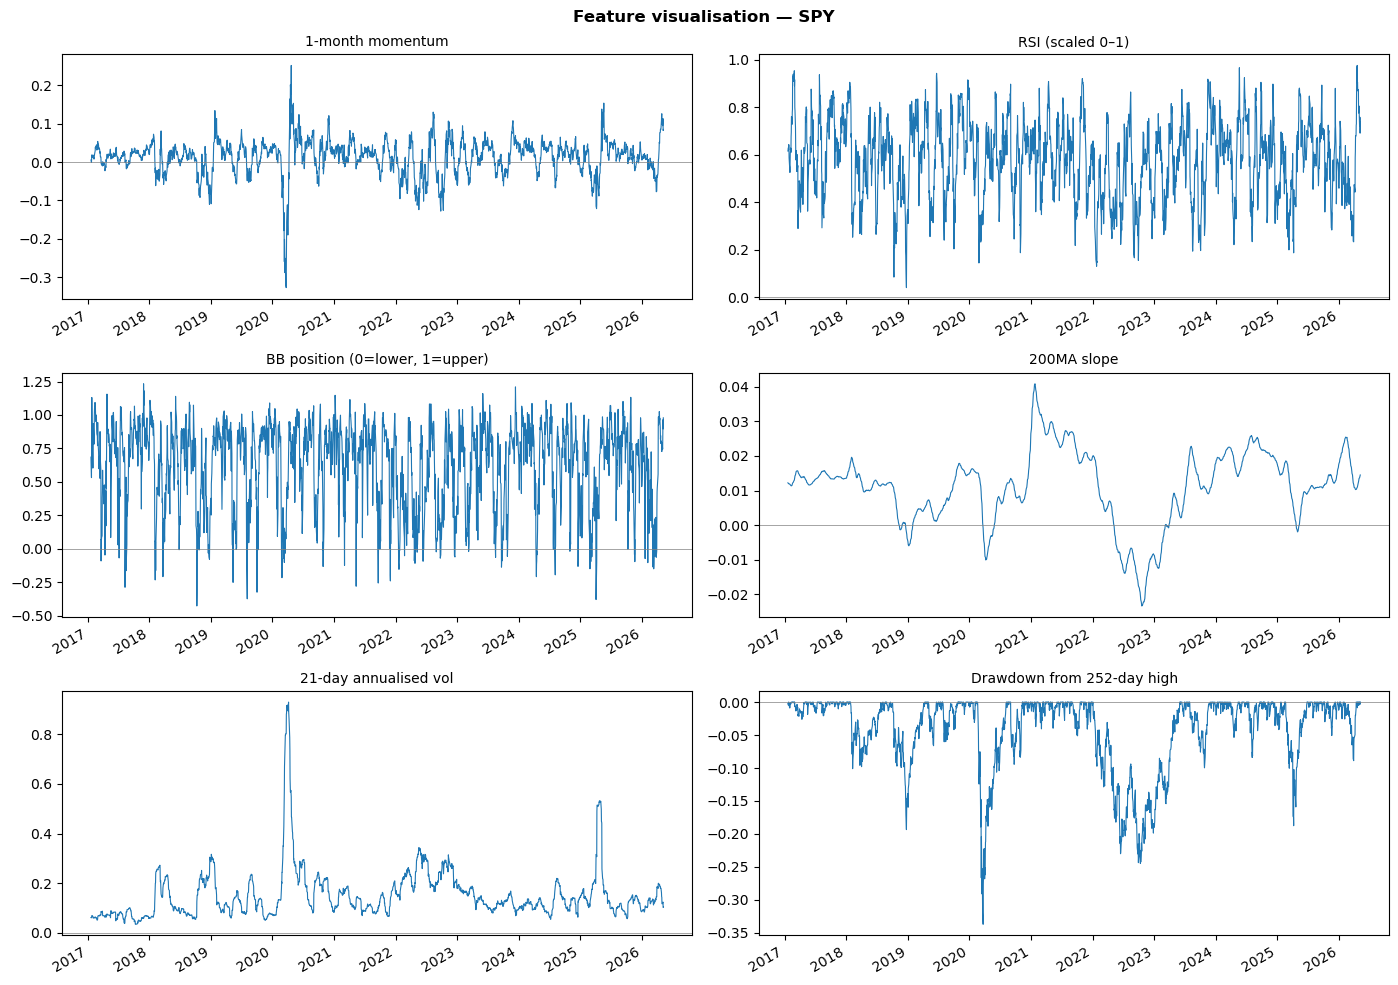

In [2]:
# Download one asset to demonstrate features
demo_asset = "SPY"
raw = yf.download(demo_asset, start=TRAIN_START, end=TEST_END,
                  auto_adjust=True, progress=False)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)
price_demo = raw["Close"].squeeze()
ohlc_demo  = raw[["High", "Low", "Close"]].copy()

features_demo = engineer_features(price_demo, ohlc_demo)

print(f"Feature matrix for {demo_asset}:")
print(f"  Shape: {features_demo.shape}  ({features_demo.shape[0]} days × {features_demo.shape[1]} features)")
print(f"  Features: {list(features_demo.columns)}")
print(f"\nLast 5 rows (most recent):")
print(features_demo.tail(5).round(4).to_string())

# Plot features over time
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

pairs = [
    ("ret_1m",  "1-month momentum"),
    ("rsi_14",  "RSI (scaled 0–1)"),
    ("bb_pos",  "BB position (0=lower, 1=upper)"),
    ("ma200_slope", "200MA slope"),
    ("vol_21",  "21-day annualised vol"),
    ("drawdown", "Drawdown from 252-day high"),
]
for ax, (col, title) in zip(axes, pairs):
    if col in features_demo.columns:
        features_demo[col].plot(ax=ax, lw=0.8)
        ax.set_title(title, fontsize=10)
        ax.axhline(0, color='grey', lw=0.5)
        ax.set_xlabel("")

plt.suptitle(f"Feature visualisation — {demo_asset}", fontweight="bold")
plt.tight_layout()
plt.show()

---
## Part 3 — Target variable and the time-split rule

**Target:** `1` if price is higher 20 days from now, `0` if lower.

**The cardinal rule of financial ML:** never let future data leak into training.
We compute `target[t] = price[t+20] > price[t]` then train only on `t < 2021-01-01`.
The model never sees anything from the test period during training.

Training period: 2017-01-20 → 2020-12-31
  Samples: 995
  Up days: 728 (73.2%)
  Down days: 267 (26.8%)

Validation period: 2021-01-04 → 2026-05-08
  Samples: 1343
  Up days: 886 (66.0%)


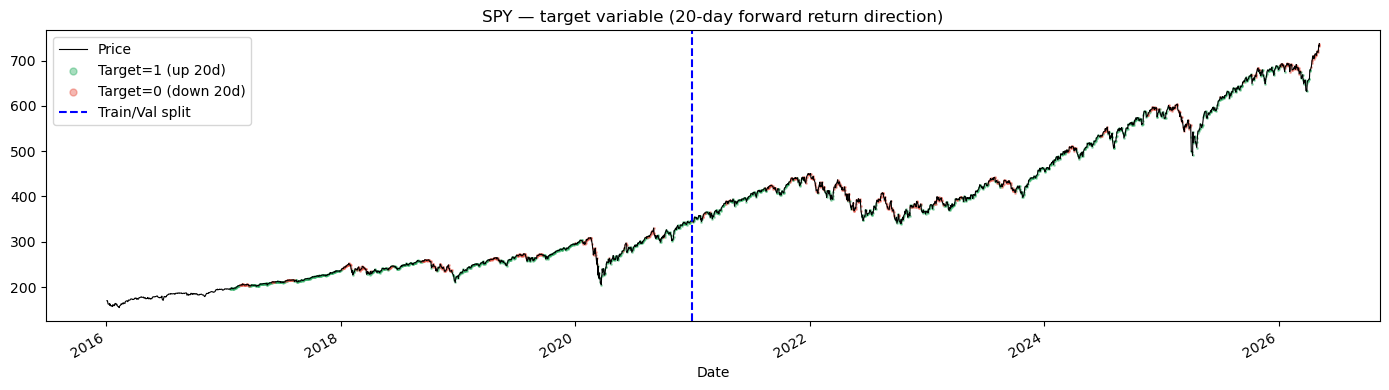

In [3]:
from ml_signal import build_target                                                                                                                                                                      
                                                            
target_demo = build_target(price_demo, LOOKFORWARD)

# Align to the common index (features drop NaN rows during warm-up)                                                                                                                                     
common_idx    = features_demo.index.intersection(target_demo.index)
X_demo        = features_demo.loc[common_idx]                                                                                                                                                           
y_demo        = target_demo.loc[common_idx]               
price_aligned = price_demo.loc[common_idx]                                                                                                                                                              
                                                            
train_mask = X_demo.index < TRAIN_END                                                                                                                                                                   
val_mask   = X_demo.index >= TRAIN_END                    

print(f"Training period: {X_demo[train_mask].index[0].date()} → {X_demo[train_mask].index[-1].date()}")                                                                                                 
print(f"  Samples: {train_mask.sum()}")
print(f"  Up days: {y_demo[train_mask].sum()} ({y_demo[train_mask].mean()*100:.1f}%)")                                                                                                                  
print(f"  Down days: {(1-y_demo[train_mask]).sum()} ({(1-y_demo[train_mask]).mean()*100:.1f}%)")                                                                                                        
print()                                                                                                                                                                                                 
print(f"Validation period: {X_demo[val_mask].index[0].date()} → {X_demo[val_mask].index[-1].date()}")                                                                                                   
print(f"  Samples: {val_mask.sum()}")                                                                                                                                                                   
print(f"  Up days: {y_demo[val_mask].sum()} ({y_demo[val_mask].mean()*100:.1f}%)")
                                                                                                                                                                                                          
fig, ax = plt.subplots(figsize=(14, 4))                   
price_demo.plot(ax=ax, color='black', lw=0.8, label='Price')                                                                                                                                            
up_days   = price_aligned.loc[y_demo[y_demo == 1].index]                                                                                                                                                
down_days = price_aligned.loc[y_demo[y_demo == 0].index]
ax.scatter(up_days.index,   up_days.values,   c='#27AE60', s=1, alpha=0.4, label='Target=1 (up 20d)')                                                                                                   
ax.scatter(down_days.index, down_days.values,  c='#E74C3C', s=1, alpha=0.4, label='Target=0 (down 20d)')                                                                                                
ax.axvline(TRAIN_END, color='blue', lw=1.5, linestyle='--', label='Train/Val split')                                                                                                                    
ax.set_title(f"{demo_asset} — target variable (20-day forward return direction)")                                                                                                                       
ax.legend(markerscale=5)                                                                                                                                                                                
plt.tight_layout(); plt.show()

---
## Part 4 — Train XGBoost and inspect feature importance

XGBoost builds many small decision trees in sequence, each correcting the errors
of the previous one. Feature importance shows which inputs the model relied on most.

We use conservative settings to fight overfitting:
- `max_depth=3` — very shallow trees, 8 leaves maximum
- `min_child_weight=20` — need 20+ samples in each leaf
- `reg_alpha=0.5, reg_lambda=2.0` — L1 + L2 regularisation penalise complexity

Model trained on SPY
  Train AUC: 0.927
  Val AUC:   0.417

  ⚠️ Overfit gap = 0.510 — model performs much better in-sample

  Today's ML Score: 55.8%
  ML Gate: PASS


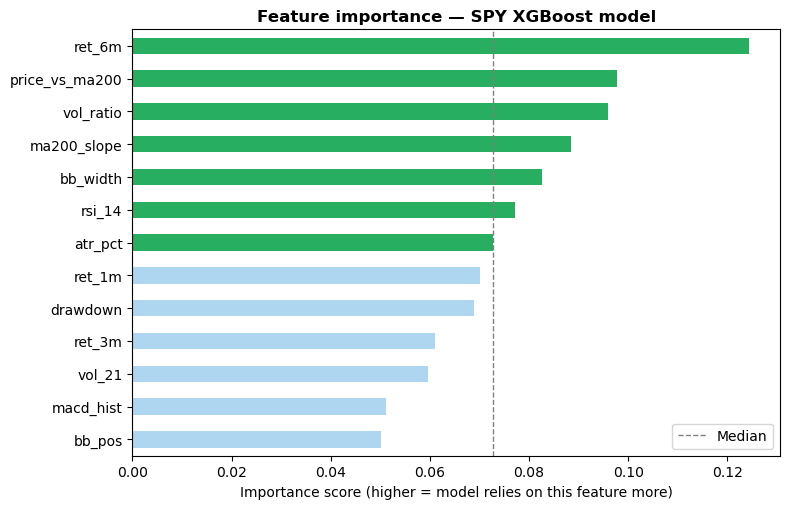

In [4]:
# Train on the demo asset
model_demo, feat_names, train_auc, val_auc = build_ml_model(
    price_demo, ohlc_demo, train_end=TRAIN_END.strftime("%Y-%m-%d")
)

print(f"Model trained on {demo_asset}")
print(f"  Train AUC: {train_auc:.3f}" if train_auc else "  Train AUC: —")
print(f"  Val AUC:   {val_auc:.3f}"   if val_auc   else "  Val AUC:   —")
print()

if train_auc and val_auc:
    gap = train_auc - val_auc
    if gap > 0.10:
        print(f"  ⚠️ Overfit gap = {gap:.3f} — model performs much better in-sample")
    elif val_auc >= 0.55:
        print(f"  ✅ Val AUC = {val_auc:.3f} — modest but real predictive signal")
    else:
        print(f"  🔵 Val AUC = {val_auc:.3f} — near-random, ML gate will have low impact")

# Current ML score
score = get_current_score(model_demo, feat_names, price_demo, ohlc_demo)
gate  = ml_gate(score)
print(f"\n  Today's ML Score: {score*100:.1f}%" if score else "  Today's ML Score: —")
print(f"  ML Gate: {gate}")

# Feature importance
if model_demo is not None:
    importances = model_demo.feature_importances_
    feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(8, max(4, len(feat_imp)*0.4)))
    colors = ['#27AE60' if v >= feat_imp.median() else '#AED6F1' for v in feat_imp]
    feat_imp.plot(kind='barh', ax=ax, color=colors)
    ax.set_title(f"Feature importance — {demo_asset} XGBoost model",
                 fontweight='bold')
    ax.set_xlabel("Importance score (higher = model relies on this feature more)")
    ax.axvline(feat_imp.median(), color='grey', lw=1, linestyle='--', label='Median')
    ax.legend()
    plt.tight_layout(); plt.show()

---
## Part 5 — Why AUC, not accuracy?

**Accuracy** asks: what % of predictions were correct?
But if 55% of days are up-days, a model that always predicts "up" has 55% accuracy — and zero skill.

**AUC (Area Under the ROC Curve)** measures how well the model *ranks* outcomes.
- 0.50 = random (coin flip)
- 0.55 = slight edge (expect modest real-world gains)
- 0.60 = solid signal
- 0.70+ = either very good or overfitting — investigate carefully

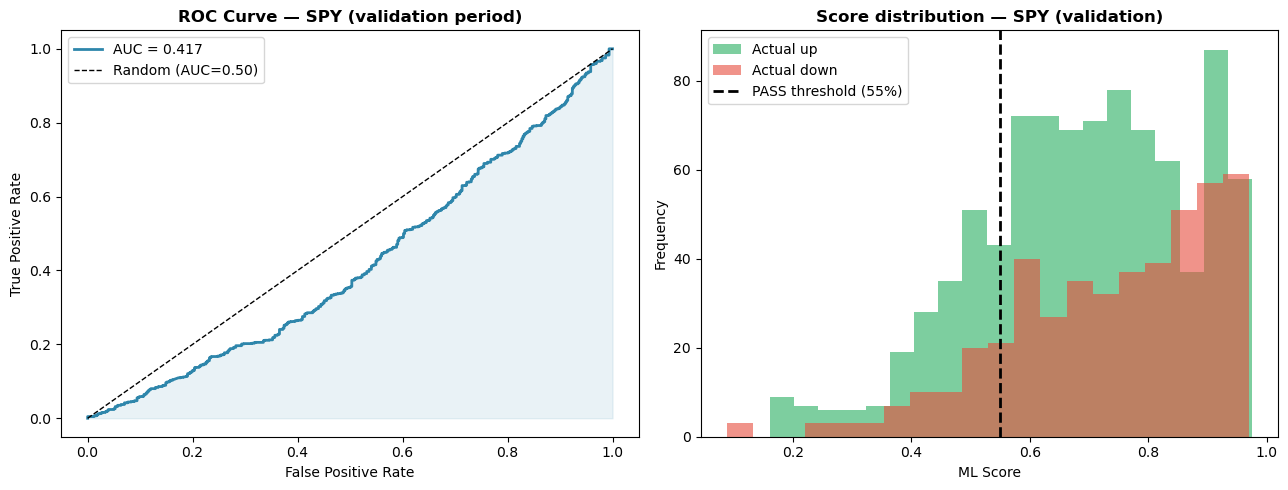

Validation AUC: 0.417
Samples in validation: 1343
PASS rate (score ≥ 55%): 80.5% of days


In [5]:
from sklearn.metrics import roc_curve, roc_auc_score

if model_demo is not None:
    common = features_demo.index.intersection(target_demo.index)
    X_all  = features_demo.loc[common]
    y_all  = target_demo.loc[common]

    val_idx = X_all.index >= TRAIN_END
    X_val   = X_all[val_idx]
    y_val   = y_all[val_idx]

    if len(X_val) > 0 and y_val.nunique() > 1:
        probs   = model_demo.predict_proba(X_val[feat_names])[:, 1]
        fpr, tpr, _ = roc_curve(y_val, probs)
        auc = roc_auc_score(y_val, probs)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

        # ROC curve
        ax1.plot(fpr, tpr, lw=2, color='#2E86AB', label=f'AUC = {auc:.3f}')
        ax1.plot([0,1],[0,1], 'k--', lw=1, label='Random (AUC=0.50)')
        ax1.fill_between(fpr, tpr, alpha=0.1, color='#2E86AB')
        ax1.set_xlabel('False Positive Rate'); ax1.set_ylabel('True Positive Rate')
        ax1.set_title(f'ROC Curve — {demo_asset} (validation period)', fontweight='bold')
        ax1.legend()

        # Score distribution
        df_scores = pd.DataFrame({'prob': probs, 'actual': y_val.values})
        ax2.hist(df_scores[df_scores['actual']==1]['prob'], bins=20,
                 alpha=0.6, color='#27AE60', label='Actual up')
        ax2.hist(df_scores[df_scores['actual']==0]['prob'], bins=20,
                 alpha=0.6, color='#E74C3C', label='Actual down')
        ax2.axvline(ML_PASS_THRESH, color='black', lw=2,
                    linestyle='--', label=f'PASS threshold ({ML_PASS_THRESH*100:.0f}%)')
        ax2.set_xlabel('ML Score'); ax2.set_ylabel('Frequency')
        ax2.set_title(f'Score distribution — {demo_asset} (validation)', fontweight='bold')
        ax2.legend()

        plt.tight_layout(); plt.show()

        print(f"Validation AUC: {auc:.3f}")
        print(f"Samples in validation: {len(X_val)}")
        print(f"PASS rate (score ≥ {ML_PASS_THRESH*100:.0f}%): "
              f"{(probs >= ML_PASS_THRESH).mean()*100:.1f}% of days")

---
## Part 6 — Full Phase 7 run (all markets)

Now we run the complete pipeline:
1. Phase 5: strategy selection + regime gate + Kelly sizing
2. Phase 6: correlation matrix + cluster-adjusted sizes
3. Phase 7: train XGBoost per asset, attach ML Score + P7 Verdict

This takes a few minutes — XGBoost trains once per asset.

In [6]:
# Download all assets
all_assets = []
for m in markets_to_run:
    all_assets.extend(UNIVERSE_MAP[m])
seen = set(); unique_assets = []
for a in all_assets:
    if a not in seen: unique_assets.append(a); seen.add(a)

print(f"Downloading {len(unique_assets)} assets...")
price_data = {}; ohlc_data = {}
for asset in unique_assets:
    try:
        raw = yf.download(asset, start=TRAIN_START, end=TEST_END,
                          auto_adjust=True, progress=False)
        if not raw.empty and len(raw) >= MIN_ROWS:
            if isinstance(raw.columns, pd.MultiIndex):
                raw.columns = raw.columns.get_level_values(0)
            close = raw["Close"].squeeze()
            if isinstance(close, pd.DataFrame): close = close.iloc[:, 0]
            price_data[asset] = close
            if {"High", "Low", "Close"}.issubset(set(raw.columns)):
                ohlc_data[asset] = raw[["High", "Low", "Close"]].copy()
    except: pass

print(f"  → {len(price_data)} assets ready\n")

# Phase 5 screening
print("Phase 5: screening...")
all_results = {}
for m in markets_to_run:
    print(f"  {m}...")
    all_results[m] = screen_market(m, UNIVERSE_MAP[m], price_data, ohlc_data)

combined = pd.concat([df for df in all_results.values() if not df.empty],
                     ignore_index=True)
print(f"\nPhase 5 done — {len(combined)} assets")

$ALU.AX: possibly delisted; no timezone found

1 Failed download:
['ALU.AX']: possibly delisted; no timezone found
$SKI.AX: possibly delisted; no timezone found

1 Failed download:
['SKI.AX']: possibly delisted; no timezone found


  → 117 assets ready

Phase 5: screening...
  US...

  ── Screening US (40 valid assets) ──
    ✅ [A] AAPL           → MACD               | Sharpe:  0.69 | Ret:     84% | DD: -20.9% | DDsaved:   +12.5% | B&H ✗ | Score: 62/100 | 🟢 Bull     → TRADE      | Size: 6%
    🔵 [B] MSFT           → MA Crossover       | Sharpe:  0.37 | Ret:     37% | DD: -21.2% | DDsaved:   +16.0% | B&H ✗ | Score: 45/100 | 🔴 Bear     → STAND DOWN | Size: 7%
    ⬜ [Skip] NVDA           → MA Crossover       | Sharpe:  0.97 | Ret:    404% | DD: -63.6% | DDsaved:    +2.7% | B&H ✗ | Score: 56/100 | 🟢 Bull     → TRADE      | Size: 11%
    🔵 [B] GOOGL          → RSI                | Sharpe:  0.16 | Ret:     22% | DD: -44.3% | DDsaved:    +0.0% | B&H ✗ | Score: 25/100 | 🔴 Bull     → STAND DOWN | Size: 8%
    ⬜ [Skip] META           → RSI                | Sharpe: -0.10 | Ret:    -17% | DD: -71.5% | DDsaved:    +5.3% | B&H ✗ | Score: 9/100 | 🟢 Sideways → TRADE      | Size: 2%
    🔵 [B] AMZN           → MA Crossover       |

In [7]:
# Phase 6: correlation + cluster sizing
from goofy_screener_phase6 import run_portfolio_construction, attach_phase6_columns

print("Phase 6: correlation matrix + cluster sizing...")
p6 = run_portfolio_construction(combined, price_data)
all_results = attach_phase6_columns(
    {m: df.copy() for m, df in all_results.items()}, p6
)
combined = pd.concat([df for df in all_results.values() if not df.empty],
                     ignore_index=True)

# Phase 7: train XGBoost per asset
from goofy_screener_phase7 import run_ml_layer

print("\nPhase 7: training XGBoost per asset...\n")
all_results = run_ml_layer(all_results, price_data, ohlc_data)
combined = pd.concat([df for df in all_results.values() if not df.empty],
                     ignore_index=True)

print(f"\n{'='*60}")
print("PHASE 7 COMPLETE")
print(f"{'='*60}")
for tier in ["S", "A", "B", "Skip"]:
    print(f"  {tier}: {len(combined[combined['Tier']==tier])}")
for v in ["TRADE", "ML HOLD", "STAND DOWN"]:
    n = len(combined[combined.get('P7 Verdict', pd.Series()) == v]) \
        if 'P7 Verdict' in combined.columns else 0
    icon = {"TRADE": "🟢", "ML HOLD": "🟡", "STAND DOWN": "🔴"}.get(v, "")
    print(f"  {icon} {v}: {n}")

Phase 6: correlation matrix + cluster sizing...

Phase 7: training XGBoost per asset...

    🟢 AAPL           | ML=74%   Gate=PASS AUC=0.52  →  TRADE
    🔴 MSFT           | ML=84%   Gate=PASS AUC=0.57  →  STAND DOWN
    🟢 NVDA           | ML=62%   Gate=PASS AUC=0.45  →  TRADE
    🔴 GOOGL          | ML=38%   Gate=HOLD AUC=0.46  →  STAND DOWN
    🟢 META           | ML=71%   Gate=PASS AUC=0.41  →  TRADE
    🟢 AMZN           | ML=58%   Gate=PASS AUC=0.54  →  TRADE
    🟢 TSLA           | ML=78%   Gate=PASS AUC=0.47  →  TRADE
    🟡 AMD            | ML=39%   Gate=HOLD AUC=0.51  →  ML HOLD
    🔴 JPM            | ML=89%   Gate=PASS AUC=0.52  →  STAND DOWN
    🟡 BAC            | ML=47%   Gate=HOLD AUC=0.56  →  ML HOLD
    🔴 GS             | ML=47%   Gate=HOLD AUC=0.42  →  STAND DOWN
    🟡 MS             | ML=32%   Gate=HOLD AUC=0.50  →  ML HOLD
    🔴 V              | ML=86%   Gate=PASS AUC=0.48  →  STAND DOWN
    🔴 MA             | ML=96%   Gate=PASS AUC=0.51  →  STAND DOWN
    🔴 BRK-B          

---
## Part 7 — Analyse the ML results

Assets with ML model: 117

Val AUC distribution:
  Mean:   0.515
  Median: 0.517
  > 0.55: 21 assets (18%)
  > 0.60: 6 assets
  < 0.50: 40 assets (model predicts wrong direction)

Phase 6 TRADE signals: 45
Phase 7 TRADE signals: 24  ← passed both gates
Phase 7 ML HOLD:       21  ← regime says trade, ML says wait

Top TRADE signals (P7):
Market  Asset Tier   Best Strategy  OUT Sharpe Today's Verdict  ML Score  Val AUC P7 Verdict
    US   TSLA    B            MACD       0.886           TRADE      78.0    0.471      TRADE
   ASX CBA.AX    S             RSI       1.046           TRADE      80.0    0.422      TRADE
    US    CAT    A            MACD       1.045           TRADE      68.1    0.588      TRADE
    US   ABBV    A             RSI       0.787           TRADE      64.6    0.512      TRADE
    US   AAPL    A            MACD       0.693           TRADE      73.6    0.517      TRADE
    US    XOM    A            MACD       0.736           TRADE      57.3    0.566      TRADE
   ASX WDS

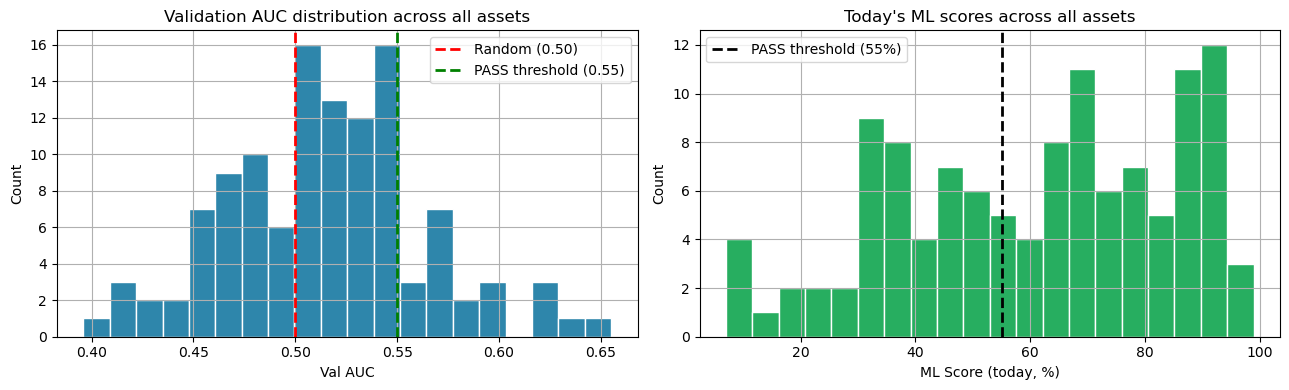

In [9]:
# Summary of ML scores and AUC across all assets
if 'ML Score' in combined.columns:
    ml_data = combined[combined['ML Score'].notna()].copy()

    print(f"Assets with ML model: {len(ml_data)}")
    print(f"\nVal AUC distribution:")
    auc_data = ml_data['Val AUC'].dropna()
    print(f"  Mean:   {auc_data.mean():.3f}")
    print(f"  Median: {auc_data.median():.3f}")
    print(f"  > 0.55: {(auc_data > 0.55).sum()} assets ({(auc_data>0.55).mean()*100:.0f}%)")
    print(f"  > 0.60: {(auc_data > 0.60).sum()} assets")
    print(f"  < 0.50: {(auc_data < 0.50).sum()} assets (model predicts wrong direction)")

    # TRADE vs ML HOLD
    trade_p6 = combined[combined["Today's Verdict"] == "TRADE"]
    trade_p7 = combined[combined.get('P7 Verdict', pd.Series()) == "TRADE"] \
               if 'P7 Verdict' in combined.columns else pd.DataFrame()
    ml_hold  = combined[combined.get('P7 Verdict', pd.Series()) == "ML HOLD"] \
               if 'P7 Verdict' in combined.columns else pd.DataFrame()

    print(f"\nPhase 6 TRADE signals: {len(trade_p6)}")
    print(f"Phase 7 TRADE signals: {len(trade_p7)}  ← passed both gates")
    print(f"Phase 7 ML HOLD:       {len(ml_hold)}  ← regime says trade, ML says wait")

    # Top TRADE signals
    if not trade_p7.empty and 'Score' in trade_p7.columns:
        display_cols = [c for c in
            ["Market", "Asset", "Tier", "Best Strategy", "OUT Sharpe",
             "Today's Verdict", "ML Score", "Val AUC", "P7 Verdict"]
            if c in trade_p7.columns]
        print(f"\nTop TRADE signals (P7):")
        print(trade_p7.sort_values("Score", ascending=False)
              [display_cols].head(15).to_string(index=False))

    # AUC histogram
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    auc_data.hist(bins=20, ax=ax1, color='#2E86AB', edgecolor='white')
    ax1.axvline(0.50, color='red', lw=2, linestyle='--', label='Random (0.50)')
    ax1.axvline(0.55, color='green', lw=2, linestyle='--', label='PASS threshold (0.55)')
    ax1.set_xlabel('Val AUC'); ax1.set_ylabel('Count')
    ax1.set_title('Validation AUC distribution across all assets')
    ax1.legend()

    ml_score_data = ml_data['ML Score'].dropna()
    ml_score_data.hist(bins=20, ax=ax2, color='#27AE60', edgecolor='white')
    ax2.axvline(ML_PASS_THRESH*100, color='black', lw=2,
                linestyle='--', label=f'PASS threshold ({ML_PASS_THRESH*100:.0f}%)')
    ax2.set_xlabel('ML Score (today, %)'); ax2.set_ylabel('Count')
    ax2.set_title("Today's ML scores across all assets")
    ax2.legend()

    plt.tight_layout(); plt.show()

---
## Part 8 — Save Phase 7 Excel report

In [10]:
from goofy_screener_phase7 import write_excel_phase7

xlsx_path = write_excel_phase7(all_results, today, p6)
print(f"Saved → {xlsx_path}")

import subprocess
try:
    subprocess.Popen(["open", xlsx_path])
    print("Excel opened.")
except: pass

Saved → /Users/hiro/quant-research/Claude project (me learning)/Quant python learning 1/screener_output/Goofy_Phase7_2026-05-11.xlsx
Excel opened.
